# Ejercicio 6 — Benchmark: Parquet directo vs. tabla DuckDB

El benchmark lo ejecuta `scripts/benchmark.py` (tarda varios minutos y genera `docs/resultados/06_benchmark.csv`).
Este notebook solo analiza y grafica esos resultados. Para re-ejecutarlo desde aquí, descomente la celda siguiente.
Las consultas medidas están en `sql/06_benchmark.sql`; el análisis está en `docs/06_benchmark.md`.

In [1]:
# !cd .. && python scripts/benchmark.py

In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
FIG = Path("docs/figuras"); FIG.mkdir(parents=True, exist_ok=True)
b = pd.read_csv("docs/resultados/06_benchmark.csv")
carga = pd.read_csv("docs/resultados/06_benchmark_carga.csv")
carga

,escenario,archivos,filas,parquet_mib,duckdb_mib,materializacion_s
0,1_mes,2,3765161,62.1,102.3,2.27
1,2026,16,30040469,495.7,816.5,9.59
2,2024+2026,40,71870407,1171.7,1940.3,31.30


## Tabla de resultados (mediana en segundos)

In [3]:
t = b.pivot_table(index="consulta", columns=["escenario", "estrategia"], values="mediana_s")
t = t.reindex(columns=carga.escenario, level=0)
for e in carga.escenario:
    t[(e, "aceleracion")] = t[(e, "parquet")] / t[(e, "tabla")]
t = t.reindex(columns=pd.MultiIndex.from_product([carga.escenario, ["parquet", "tabla", "aceleracion"]]))
t.round(3)

escenario             1_mes                       2026                     \
                    parquet  tabla aceleracion parquet  tabla aceleracion   
consulta                                                                    
B1_conteo_total       0.026  0.000     132.500   0.140  0.000     466.000   
B2_viajes_por_mes     0.318  0.043       7.460   1.206  0.257       4.686   
B3_demanda_hora_dia   0.501  0.062       8.022   2.282  0.379       6.016   
B4_top_zonas          0.343  0.052       6.567   1.323  0.319       4.143   
B5_propinas           0.355  0.095       3.750   1.824  0.946       1.928   
B6_percentiles        0.911  0.632       1.442   6.015  5.080       1.184   
B7_un_dia             0.092  0.003      28.812   0.222  0.003      74.033   
B8_filas_completas    0.924  0.303       3.053   2.353  0.782       3.008   

escenario           2024+2026                      
                      parquet   tabla aceleracion  
consulta                                           
B1_conteo_total         0.294   0.000     979.667  
B2_viajes_por_mes       2.590   0.531       4.880  
B3_demanda_hora_dia     4.936   0.785       6.284  
B4_top_zonas            2.751   0.626       4.397  
B5_propinas             4.343   2.111       2.057  
B6_percentiles         12.214  10.496       1.164  
B7_un_dia               0.982   0.003     288.765  
B8_filas_completas      4.448   1.023       4.348

## Tiempo vs. cantidad de datos

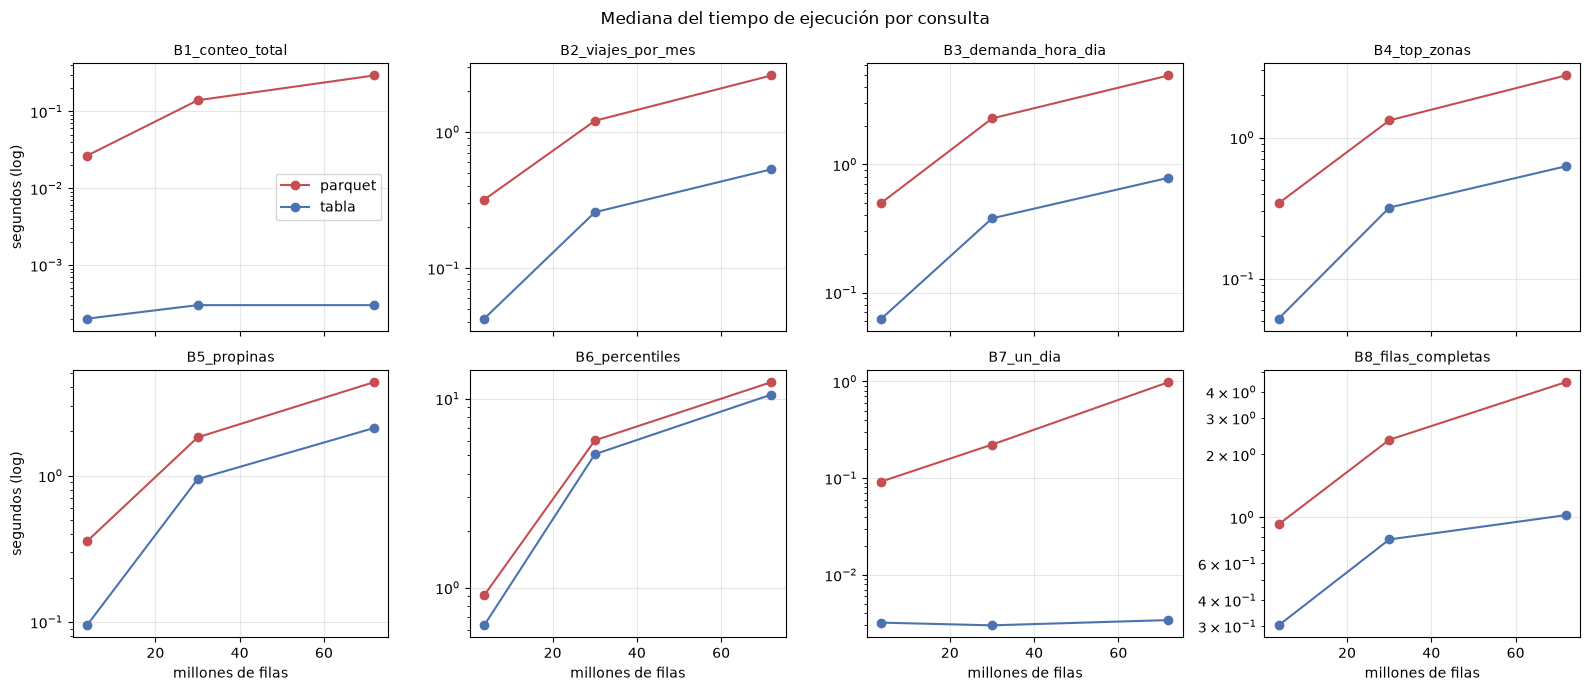

In [4]:
consultas = sorted(b.consulta.unique())
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
for ax, q in zip(axes.flat, consultas):
    for est, color in (("parquet", "#c44e52"), ("tabla", "#4c72b0")):
        d = b[(b.consulta == q) & (b.estrategia == est)].sort_values("filas")
        ax.plot(d.filas / 1e6, d.mediana_s, marker="o", color=color, label=est)
    ax.set_title(q, fontsize=10); ax.set_yscale("log")
    ax.grid(alpha=.3)
for ax in axes[-1]: ax.set_xlabel("millones de filas")
for ax in axes[:, 0]: ax.set_ylabel("segundos (log)")
axes[0, 0].legend()
fig.suptitle("Mediana del tiempo de ejecución por consulta")
plt.tight_layout()
fig.savefig(FIG / "06_tiempo_vs_filas.png", dpi=110, bbox_inches="tight")

## Aceleración de la tabla materializada (Parquet / tabla)

escenario,1_mes,2026,2024+2026
consulta,,,
B1_conteo_total,132.5,466.0,979.7
B2_viajes_por_mes,7.5,4.7,4.9
B3_demanda_hora_dia,8.0,6.0,6.3
B4_top_zonas,6.6,4.1,4.4
B5_propinas,3.7,1.9,2.1
B6_percentiles,1.4,1.2,1.2
B7_un_dia,28.8,74.0,288.8
B8_filas_completas,3.1,3.0,4.3


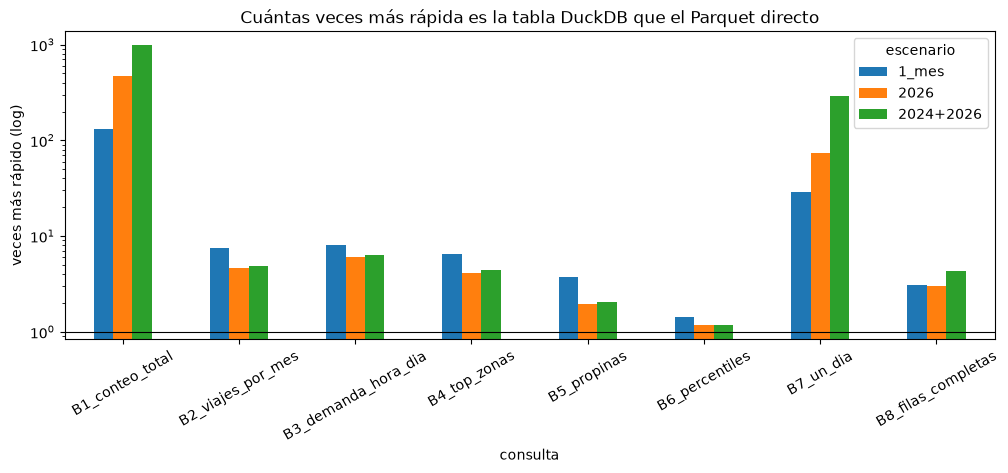

In [5]:
a = b.pivot_table(index=["escenario", "consulta"], columns="estrategia", values="mediana_s")
a["aceleracion"] = a.parquet / a.tabla
p = a.aceleracion.unstack(0)[list(carga.escenario)]
ax = p.plot.bar(figsize=(12, 4), logy=True, rot=30)
ax.axhline(1, color="black", lw=.8); ax.set_ylabel("veces más rápido (log)")
ax.set_title("Cuántas veces más rápida es la tabla DuckDB que el Parquet directo")
ax.figure.savefig(FIG / "06_aceleracion.png", dpi=110, bbox_inches="tight")
p.round(1)

## Costo de materializar

In [6]:
c = carga.copy()
c["ahorro_total_s"] = [ (b[(b.escenario == e) & (b.estrategia == "parquet")].mediana_s.sum()
                         - b[(b.escenario == e) & (b.estrategia == "tabla")].mediana_s.sum())
                        for e in c.escenario ]
c["ejecuciones_para_amortizar"] = (c.materializacion_s / c.ahorro_total_s).round(1)
c["sobrecosto_disco"] = (c.duckdb_mib / c.parquet_mib).round(2)
c

,escenario,archivos,filas,parquet_mib,duckdb_mib,materializacion_s,ahorro_total_s,ejecuciones_para_amortizar,sobrecosto_disco
0,1_mes,2,3765161,62.1,102.3,2.27,2.2811,1.0,1.65
1,2026,16,30040469,495.7,816.5,9.59,7.5968,1.3,1.65
2,2024+2026,40,71870407,1171.7,1940.3,31.30,16.9828,1.8,1.66
